# 01 — Parse, exclusions and splits (M1)

**Goal:** turn the raw tarball into one parsed table, drop the excluded molecules, and build every split that
later milestones train and test on.

M1 acceptance criteria (PLAN §9.4):
- parsed table saved; parser tested on known molecules (`tests/test_parser.py`);
- exclusions applied and documented (`docs/DATA.md`);
- all split files written to `splits/`, every PLAN §4 assert passes, and a split report is printed.

Split settings live in `configs/splits.yaml`. Run with the project environment as the kernel (README.md, "Setup");
every cell is safe to re-run.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.15, 15 pinned packages checked, 0 differ; repo C:\Users\dougl\OneDrive\Documents\dev_projects\Quantum_hackathon\QML_project


## 1. Parse the tarball into one table

The tarball is streamed (never extracted) and parsed once into `data/processed/qm9.parquet`. Re-runs load the parquet
in about a second. Set `REBUILD = True` only after changing the parser.

Only atomic numbers `Z`, coordinates `R` (Å) and the label `mu` (debye) are kept as model-relevant columns. The
Mulliken charges and the other 14 DFT properties are dropped at parse time, so they cannot leak into features.

In [2]:
import json

import numpy as np
import pandas as pd

from qm9dipole import REPO_ROOT
from qm9dipole.data import QM9_PARQUET, build_qm9_table, load_qm9_table, save_qm9_table

REBUILD = False

if REBUILD or not QM9_PARQUET.exists():
    table, failures = build_qm9_table()
    print(f"parsed {len(table):,} molecules; {len(failures)} parse failures")
    for name, err in failures:
        print("  ", name, err)
    assert not failures, "parse failures must be fixed or documented in docs/DATA.md"
    save_qm9_table(table)

table = load_qm9_table()
print(f"{len(table):,} molecules loaded from {QM9_PARQUET.relative_to(REPO_ROOT)} "
      f"({QM9_PARQUET.stat().st_size / 1e6:.1f} MB)")
table.head(3)

133,885 molecules loaded from data\processed\qm9.parquet (61.6 MB)


,id,formula,n_atoms,n_heavy,Z,R,mu,smiles
0,1,CH4,5,1,"[6, 1, 1, 1, 1]","[[-0.0126981359, 1.0858041578, 0.0080009958], ...",0.0000,C
1,2,H3N,4,1,"[7, 1, 1, 1]","[[-0.0404260543, 1.0241077531, 0.0625637998], ...",1.6256,N
2,3,H2O,3,1,"[8, 1, 1]","[[-0.0343604951, 0.9775395708, 0.0076015923], ...",1.8511,O


In [3]:
assert len(table) == 133_885 and table["id"].is_unique
assert (table["mu"] >= 0).all(), "a dipole magnitude cannot be negative"
assert set(np.concatenate(table["Z"].to_numpy())) <= {1, 6, 7, 8, 9}

print(f"distinct formulas : {table['formula'].nunique()}")
print(f"atoms per molecule: {table['n_atoms'].min()}–{table['n_atoms'].max()}, "
      f"heavy atoms: {table['n_heavy'].min()}–{table['n_heavy'].max()}")
print(f"mu (debye)        : min {table['mu'].min():.2f}, median {table['mu'].median():.2f}, "
      f"max {table['mu'].max():.2f}")
table.loc[table["id"].isin([1, 2, 3]), ["id", "formula", "n_atoms", "mu", "smiles"]]

distinct formulas : 621
atoms per molecule: 3–29, heavy atoms: 1–9
mu (debye)        : min 0.00, median 2.50, max 29.56


,id,formula,n_atoms,mu,smiles
0,1,CH4,5,0.0000,C
1,2,H3N,4,1.6256,N
2,3,H2O,3,1.8511,O


## 2. Exclusions

Rules apply in order, and the report counts how many IDs each rule *newly* removes, since the readme's hard-to-converge
list partly overlaps `uncharacterized.txt`.

In [4]:
from qm9dipole.data import apply_exclusions, exclusion_rules
from qm9dipole.splits import load_config

cfg = load_config()
rules = exclusion_rules(include_readme_flagged=cfg["exclude_readme_flagged"])
kept, exclusion_report, excluded = apply_exclusions(table, rules)

print(f"kept {len(kept):,} of {len(table):,} molecules ({len(excluded):,} excluded)")
exclusion_report

kept 130,823 of 133,885 molecules (3,062 excluded)


,rule,listed,newly_removed
0,uncharacterized.txt,3054,3054
1,readme: difficult to converge,11,8


## 3. Build and check the splits

`build_splits` follows PLAN §4 step by step: working pool → unseen formulas → familiar formulas → training pool →
per-seed anchors and nested training sets. `check_splits` then runs every PLAN §4 assert, (a)–(g), plus (h): each
test set draws only from its own formulas. Each assert also has a unit test that deliberately breaks it.

In [5]:
from qm9dipole.provenance import config_hash
from qm9dipole.splits import build_splits, check_splits

splits = build_splits(kept, cfg)
check_splits(splits, table, excluded)
print(f"all split checks passed  (config_hash {config_hash(cfg)})")

all split checks passed  (config_hash da596c9e207c)


## 4. Working pool (PLAN §3.5)

At most 25 molecules per formula, so the pool keeps every formula while no single formula dominates. These plots are
descriptive; nothing is tuned on them.

In [6]:
pool = kept[kept["id"].isin(splits.pool)]
print(f"working pool: {len(pool):,} molecules, {pool['formula'].nunique()} formulas "
      f"(from {len(kept):,} molecules, {kept['formula'].nunique()} formulas after exclusions)")

per_formula = pool.groupby("formula").size()
print(f"molecules per formula in the pool: median {per_formula.median():.0f}, "
      f"{(per_formula == 25).sum()} formulas capped at 25, {(per_formula < 3).sum()} with fewer than 3")

by_heavy = pd.DataFrame({
    "formulas": pool.groupby("n_heavy")["formula"].nunique(),
    "molecules": pool.groupby("n_heavy").size(),
})
by_heavy.index.name = "heavy atoms"
by_heavy.T

working pool: 8,438 molecules, 616 formulas (from 130,823 molecules, 616 formulas after exclusions)
molecules per formula in the pool: median 12, 240 formulas capped at 25, 144 with fewer than 3


heavy atoms,1,2,3,4,5,6,7,8,9
formulas,3,5,7,20,31,64,92,162,232
molecules,3,5,9,31,127,521,1265,2371,4106


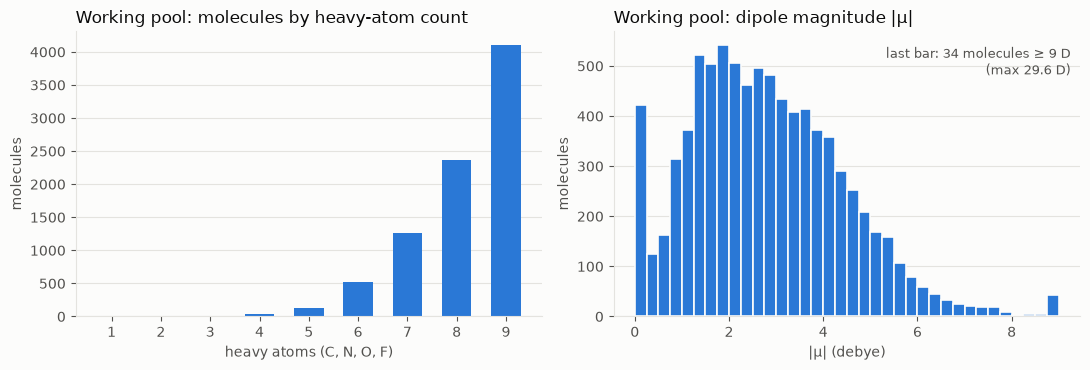

In [7]:
import matplotlib.pyplot as plt

SURFACE, INK, INK_2, GRID, SERIES = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"

mu_cap = float(np.ceil(pool["mu"].quantile(0.995)))
n_beyond = int((pool["mu"] > mu_cap).sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), facecolor=SURFACE)
ax1.bar(by_heavy.index, by_heavy["molecules"], width=0.6, color=SERIES, zorder=2)
ax1.set_xticks(by_heavy.index)
ax1.set_title("Working pool: molecules by heavy-atom count", loc="left", color=INK)
ax1.set_xlabel("heavy atoms (C, N, O, F)", color=INK_2)
ax1.set_ylabel("molecules", color=INK_2)

ax2.hist(pool["mu"].clip(upper=mu_cap), bins=np.arange(0, mu_cap + 0.25, 0.25),
         color=SERIES, edgecolor=SURFACE, linewidth=1.2, zorder=2)
ax2.set_title("Working pool: dipole magnitude |μ|", loc="left", color=INK)
ax2.set_xlabel("|μ| (debye)", color=INK_2)
ax2.text(0.98, 0.95, f"last bar: {n_beyond} molecules ≥ {mu_cap:.0f} D\n(max {pool['mu'].max():.1f} D)",
         transform=ax2.transAxes, ha="right", va="top", color=INK_2, fontsize=9)
ax2.set_ylabel("molecules", color=INK_2)

for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=INK_2)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "m1_pool_overview.png", dpi=150, facecolor=SURFACE)
plt.show()

## 5. Split report

**Test sets** are fixed by the split seed. **Training sets** S_(s,N) are nested for each training seed s.

In [8]:
formula = table.set_index("id")["formula"]
fam = set(splits.familiar_formulas)

print(f"unseen formulas : {len(splits.unseen_formulas)} of {pool['formula'].nunique()} "
      f"→ unseen test set {len(splits.test_unseen)} molecules")
print(f"familiar formulas: {len(fam)} → familiar test set {len(splits.test_familiar)} molecules")

unseen_heavy = pool[pool["formula"].isin(splits.unseen_formulas)].groupby("n_heavy")["formula"].nunique()
print("unseen formulas per heavy-atom count:", unseen_heavy.to_dict())

rows = []
for seed, by_n in splits.train.items():
    for n, ids in by_n.items():
        rows.append({"seed": seed, "N": n, "formulas": formula.loc[ids].nunique(),
                     "anchors": len(splits.anchors[seed]),
                     "anchor share": len(splits.anchors[seed]) / n,
                     "familiar formulas covered": len(fam & set(formula.loc[ids]))})
pd.DataFrame(rows).style.format({"anchor share": "{:.0%}"}).hide(axis="index")

unseen formulas : 93 of 616 → unseen test set 370 molecules
familiar formulas: 40 → familiar test set 80 molecules
unseen formulas per heavy-atom count: {2: 1, 3: 1, 4: 3, 5: 5, 6: 10, 7: 14, 8: 24, 9: 35}


seed,N,formulas,anchors,anchor share,familiar formulas covered
0,100,93,40,40%,40
0,300,202,40,13%,40
0,1000,360,40,4%,40
1,100,85,40,40%,40
1,300,207,40,13%,40
1,1000,362,40,4%,40
2,100,85,40,40%,40
2,300,206,40,13%,40
2,1000,352,40,4%,40


### Anchor skew (PLAN §4 note)

Anchors guarantee that every familiar formula appears in the smallest training set, but they also over-represent those
formulas there. Below, the share of each training set drawn from familiar formulas is compared with their share of the
training pool P, which is what a plain random sample would give. This uses formulas only, no labels or test results.

In [9]:
P = pool[~pool["formula"].isin(splits.unseen_formulas) & ~pool["id"].isin(splits.test_familiar)]
p_share = P["formula"].isin(fam).mean()

skew = pd.DataFrame(
    {f"S_(s,{n})": [formula.loc[splits.train[s][n]].isin(fam).mean() for s in splits.train]
     for n in sorted(cfg["train_sizes"])},
    index=pd.Index(list(splits.train), name="seed"),
)
skew["training pool P"] = p_share
print(f"training pool P: {len(P):,} molecules")
skew.style.format("{:.0%}")

training pool P: 7,131 molecules


,"S_(s,100)","S_(s,300)","S_(s,1000)",training pool P
seed,,,,
0,43%,21%,12%,9%
1,47%,20%,12%,9%
2,50%,23%,13%,9%


In [10]:
def heavy_tvd(ids):
    """Total variation distance between the heavy-atom-count mix of `ids` and of P (0 = identical)."""
    p = P["n_heavy"].value_counts(normalize=True)
    q = table.set_index("id").loc[ids, "n_heavy"].value_counts(normalize=True)
    return 0.5 * p.subtract(q, fill_value=0).abs().sum()

pd.DataFrame(
    {f"S_(s,{n})": [heavy_tvd(splits.train[s][n]) for s in splits.train] for n in sorted(cfg["train_sizes"])},
    index=pd.Index(list(splits.train), name="seed"),
).style.format("{:.3f}")

,"S_(s,100)","S_(s,300)","S_(s,1000)"
seed,,,
0,0.082,0.056,0.024
1,0.074,0.062,0.023
2,0.123,0.080,0.039


## 6. Save the splits

One JSON file per set in `splits/`, each stamped with the split seed, `config_hash` and `git_hash`. `meta.json` also
records the config, both formula lists and the exclusion counts. These files are committed, so every later milestone
uses exactly these molecules.

In [11]:
from qm9dipole.splits import load_splits, save_splits

paths = save_splits(splits, extra_meta={
    "n_parsed": len(table),
    "n_kept": len(kept),
    "exclusions": json.loads(exclusion_report.to_json(orient="records")),
})
print(f"wrote {len(paths)} files to splits/:", ", ".join(p.name for p in paths))

reloaded = load_splits()
check_splits(reloaded, table, excluded)
assert all(np.array_equal(reloaded.all_id_arrays()[k], v) for k, v in splits.all_id_arrays().items())
print("reloaded splits are identical and pass all checks")

wrote 13 files to splits/: meta.json, pool.json, test_unseen.json, test_familiar.json, train_s0_n100.json, train_s0_n300.json, train_s0_n1000.json, train_s1_n100.json, train_s1_n300.json, train_s1_n1000.json, train_s2_n100.json, train_s2_n300.json, train_s2_n1000.json


reloaded splits are identical and pass all checks


In [12]:
import subprocess
import sys

r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "tests/test_parser.py", "tests/test_splits.py"],
                   cwd=REPO_ROOT, capture_output=True, text=True)
print(r.stdout[-1500:])
assert r.returncode == 0, "tests failed"

............................                                             [100%]
28 passed in 1.21s



## M1 status

If every cell ran, M1's acceptance criteria are met. Review the **anchor skew** tables before M3: if the smallest
training sets look too skewed toward familiar formulas, lower `n_familiar_formulas` in `configs/splits.yaml`, log
the change in `docs/DECISIONS.md`, and re-run this notebook. That decision must be made before any test-set result is seen.

**Next (M2):** composition and Coulomb-matrix descriptors, with rotation, translation and relabeling invariance tests.